<a href="https://colab.research.google.com/github/sayu0303/CONTROLE-2025/blob/main/CONTROLE_2611.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [148]:
! pip install -qq control

In [149]:
import control as ct
import matplotlib.pyplot as plt

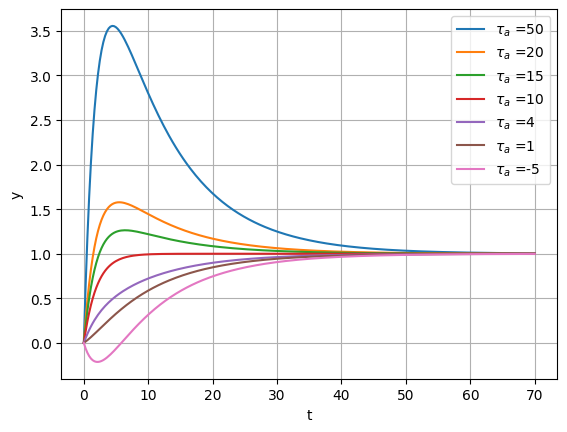

In [150]:
tau_a = [50, 20,15, 10, 4, 1,-5]
s = ct.tf('s')
delta_u = 0.5
for ta in tau_a:
  G = 2*(ta*s+1)/((10*s+1)*(2*s+1))
  #ct.pzmap(G, plot=True) para descobrir os polos no plano

  t, y = ct.step_response(G, T=70) # aqui, ele ta saindo com o degrau unitário, deve-se corrigir para entrar na simulção
  plt.plot(t, delta_u*y, label=r'$\tau_a$ ='+ str(ta))
plt.xlabel('t')
plt.ylabel('y')
plt.grid()
plt.legend()
plt.show()





In [151]:
#regra da metade

G = 5*(-0.1*s + 1)/((5*s+1)*(3*s+1)*(0.5*s+1))

print('Os polos são:', ct.poles(G))
print('Os zeros são:', ct.zeros(G))

#ct.pzmap(G, plot=True)
#print(G)

Os polos são: [-2.        +0.j -0.33333333+0.j -0.2       +0.j]
Os zeros são: [10.+0.j]


/tmp/ipython-input-290854593.py:6: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  plt.legend()


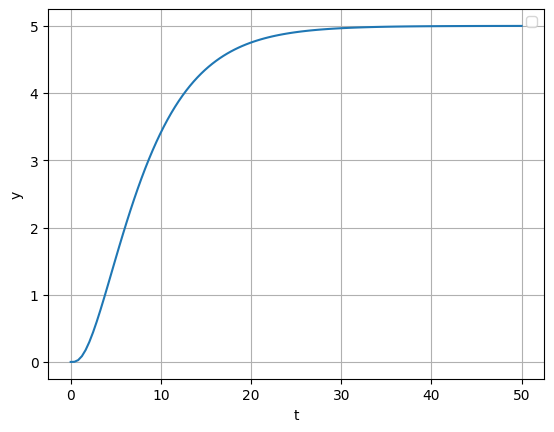

In [152]:
t, y = ct.step_response(G, T=50)
plt.plot(t,y)
plt.xlabel('t')
plt.ylabel('y')
plt.grid()
plt.legend()
plt.show()

In [153]:
num,den = ct.pade(2.1,5,2)
G_delay1 = ct.tf(num,den)


num,den = ct.pade(0.25,1,1)
G_delay2 = ct.tf(num,den)


G1 = 5/(6.5*s+1)*G_delay1
G2 = 5/((5*s+1)*(3.25*s+1))*G_delay2

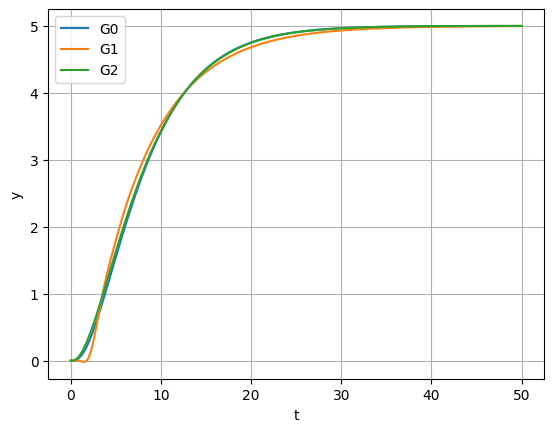

In [154]:
i=0
for g in [G, G1, G2]:
  t, y = ct.step_response(g, T=50)
  plt.plot(t,y, label ='G' +str(i))
  i += 1


plt.xlabel('t')
plt.ylabel('y')
plt.grid()
plt.legend()
plt.show()
